# Module 15: Text Categorization (Detailed)


## 🗂️ Text Categorization (TextCat)

Instead of finding specific entities *inside* a document, Text Categorization assigns labels to the **entire document**.
This is crucial for Sentiment Analysis, Spam Detection, Support Ticket Routing, and Intent Classification in chatbots.

### Exclusive vs Non-Exclusive
spaCy provides two different components for TextCat:
1. **`textcat` (Exclusive/Mutually Exclusive):** A document can only have ONE true category. E.g., An email is either `SPAM` or `HAM`, not both. The probabilities of all categories will sum to 1.0 (Softmax).
2. **`textcat_multilabel` (Non-Exclusive):** A document can have MULTIPLE true categories simultaneously. E.g., A movie review can be both `ACTION` and `COMEDY`. The probabilities are calculated independently (Sigmoid).


<br><br>

---

<br><br>


### 1. Generating TextCat Data

The data format is different from NER. Instead of character offsets, we provide a dictionary of boolean/float flags for every possible category.


In [1]:
import spacy
from spacy.tokens import DocBin

# Let's build a Support Ticket Router
# Categories: BILLING, TECHNICAL, GENERAL

TEXTCAT_DATA = [
    ("My credit card was charged twice this month.", {
        "cats": {"BILLING": 1.0, "TECHNICAL": 0.0, "GENERAL": 0.0}
    }),
    ("The website keeps crashing when I click login.", {
        "cats": {"BILLING": 0.0, "TECHNICAL": 1.0, "GENERAL": 0.0}
    }),
    ("What are your business hours?", {
        "cats": {"BILLING": 0.0, "TECHNICAL": 0.0, "GENERAL": 1.0}
    }),
    ("I need a refund, the software throws an error 500.", {
        # Notice this one could technically be both! If we use textcat_multilabel, we can set both to 1.0
        "cats": {"BILLING": 1.0, "TECHNICAL": 1.0, "GENERAL": 0.0}
    })
]

def convert_textcat_data(data, output_file):
    nlp = spacy.blank("en")
    db = DocBin()
    
    for text, annot in data:
        doc = nlp.make_doc(text)
        # Assign the dictionary directly to doc.cats
        doc.cats = annot["cats"]
        db.add(doc)
        
    db.to_disk(output_file)
    print(f"Saved {len(data)} examples to {output_file}")

convert_textcat_data(TEXTCAT_DATA, "train_textcat.spacy")


Saved 4 examples to train_textcat.spacy


<br><br>

---

<br><br>


### 2. Generating the TextCat Config

To generate the config, we change `--pipeline ner` to `--pipeline textcat` (or `textcat_multilabel`).


In [2]:
import os

# Generate the config for an exclusive textcat model
os.system("python -m spacy init config config_textcat.cfg --lang en --pipeline textcat --optimize efficiency --force")
print("config_textcat.cfg generated!")


config_textcat.cfg generated!


<br><br>

---

<br><br>


### 3. Evaluating TextCat (Macro F1 & Confusion Matrices)

In classification tasks, **Accuracy** is often a terrible metric.
Imagine a dataset with 990 `GENERAL` tickets and 10 `BILLING` tickets.
If your model is broken and *always* outputs `GENERAL` no matter what, its Accuracy is **99%**!

Instead, spaCy evaluates using the **Macro F1 Score**. It calculates the precision/recall for `BILLING`, calculates it for `GENERAL`, and averages them together. In the broken model above, the Macro F1 would be terrible (~49%), exposing the flaw.

#### The Confusion Matrix
A Confusion Matrix shows exactly where the model is confused. You can build one using `scikit-learn` and `matplotlib` based on the predicted `doc.cats`.


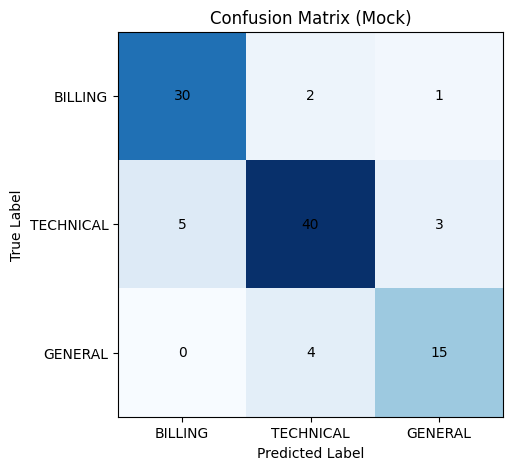

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Mock function to simulate rendering a confusion matrix
def plot_mock_confusion_matrix():
    categories = ["BILLING", "TECHNICAL", "GENERAL"]
    # Let's pretend our model predicted 100 tickets
    # Rows: Actual, Columns: Predicted
    matrix = np.array([
        [30,  2,  1],  # Actual BILLING
        [ 5, 40,  3],  # Actual TECHNICAL
        [ 0,  4, 15]   # Actual GENERAL
    ])
    
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matrix, cmap="Blues")
    
    ax.set_xticks(np.arange(len(categories)))
    ax.set_yticks(np.arange(len(categories)))
    ax.set_xticklabels(categories)
    ax.set_yticklabels(categories)
    
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix (Mock)")
    
    for i in range(len(categories)):
        for j in range(len(categories)):
            text = ax.text(j, i, matrix[i, j], ha="center", va="center", color="black")
            
    plt.show()

plot_mock_confusion_matrix()


<br><br>

---

<br><br>


### 4. Reading Predictions in Production

When running a trained TextCat model in production, the predictions are stored in `doc.cats`. It returns a dictionary of probabilities. You have to sort them to find the highest one!


In [4]:
"""
# Load your trained model
nlp = spacy.load("./textcat_models/model-best")

doc = nlp("I cannot login, the server is down.")

# doc.cats looks like: {"BILLING": 0.05, "TECHNICAL": 0.91, "GENERAL": 0.04}
print("Raw Probabilities:", doc.cats)

# Find the category with the highest score
best_category = max(doc.cats, key=doc.cats.get)
best_score = doc.cats[best_category]

print(f"\nPrediction: {best_category} (Confidence: {best_score:.2%})")
"""


'\n# Load your trained model\nnlp = spacy.load("./textcat_models/model-best")\n\ndoc = nlp("I cannot login, the server is down.")\n\n# doc.cats looks like: {"BILLING": 0.05, "TECHNICAL": 0.91, "GENERAL": 0.04}\nprint("Raw Probabilities:", doc.cats)\n\n# Find the category with the highest score\nbest_category = max(doc.cats, key=doc.cats.get)\nbest_score = doc.cats[best_category]\n\nprint(f"\nPrediction: {best_category} (Confidence: {best_score:.2%})")\n'